# Miners are capitulating. Is that when you buy? ⛏️🎗️
### Hash Ribbons — a genuinely clever signal that has only fired **four** times in Bitcoin's history

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats_random_buy_dates%3F: Busted](https://img.shields.io/badge/Beats_random_buy_dates%3F-Busted-8b949e?style=flat-square)

Bitcoin mining is a brutal, thin-margin business. When the price drops or the network gets more competitive, the *weakest* miners — the ones with the oldest machines and the most expensive electricity — get shut off first. Some of them sell their Bitcoin stash on the way out, just to cover the bills.

**Hash Ribbons** watches for exactly that: a real, hard-to-fake drop in the network's total computing power ("hashrate"), followed by a recovery. The claim: once the weak hands are gone and hashrate turns back up, the selling pressure is over — and that moment has historically been a great time to buy.

> 📓 **Plain-language layer.** Want the *t*-stats and the placebo test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** This signal has fired **4 times** since 2014. Everything below should be read with that number tattooed on your forearm. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hash_ribbons import data, strategy as st

HR = data.hashrate_daily()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    BTC = data.load_btc()
    SIG = st.capitulation_signals(HR)
else:
    BTC = SIG = None
print("real cache present:", HAVE_REAL, "| hashrate path points:", len(HR),
      "| signals:", (0 if SIG is None else len(SIG)))

# frozen headline numbers (mirror of docs/results.md)
R = {'hr_lo': '2014-01-31', 'hr_hi': '2026-05-31', 'hr_n': 4504, 'btc_lo': '2014-09-17', 'btc_hi': '2026-06-30', 'btc_n': 4305, 'fp_btc': '9529d5277775', 'n_signals': 4, 'signals': [{'date': '2019-02-12', 'days': 105, 'window': '2018-10-30 -> 2019-02-11', 'decline': -19.7}, {'date': '2020-04-30', 'days': 30, 'window': '2020-03-31 -> 2020-04-29', 'decline': -8.1}, {'date': '2020-06-30', 'days': 31, 'window': '2020-05-30 -> 2020-06-29', 'decline': -8.1}, {'date': '2021-08-15', 'days': 89, 'window': '2021-05-18 -> 2021-08-14', 'decline': -43.9}], 'fwd': {30: (10.3, 9.7, 5.9, 22.93, 0.97, 0.3076), 90: (49.1, 32.6, 21.06, 53.69, 1.27, 0.1358), 180: (112.7, 122.6, 51.46, 104.23, 1.15, 0.1278), 365: (246.1, 233.0, 146.83, 268.65, 0.78, 0.1815)}, 'placebo_draws': 20000, 'n_entries': 3, 'years': 7.4, 'strat_total': 769.8, 'strat_cagr': 34.07, 'strat_sharpe': 1.1, 'exposure': 22.4, 'bh_total': 1502.8, 'bh_cagr': 45.65, 'bh_sharpe': 0.92, 'syn_null_mean': -0.27, 'syn_null_sd': 1.29, 'syn_null_fire': 2, 'syn_planted_t': 4.03}


real cache present: True | hashrate path points: 4504 | signals: 4


## The answer first

| Question | Answer |
|---|---|
| How many times has this actually fired? | **Just 4**, in over twelve years of Bitcoin history: 2019, twice in 2020, and 2021. |
| Did BTC rally afterward? | **Every single time**, at every horizon we checked (1, 3, 6 and 12 months) — averaging **+113%** over the six months after a signal, versus **+51%** in a randomly-chosen six months. |
| So... it works? | **We can't say that.** With only 4 events, a coin-flip-picked calendar of 4 random dates does as well or better than the signal **about 1 time in 8** — nowhere near rare enough to call it proof. |
| Could you have traded it? | You'd have beaten buy-and-hold on *risk-adjusted* terms (Sharpe 1.10 vs 0.92) — but you'd have ended up with **less than half** the money (+770% vs +1503%) because you'd have been in cash 78% of the time, missing most of the ride. |

> Four data points is not a strategy. It's an interesting coincidence with a believable story attached.

## 1 · The claim

> *"When miners capitulate — the weakest ones shutting off their machines and dumping their BTC to survive — the selling pressure that was weighing on price disappears right as the strongest miners consolidate control. Watch the 30-day hashrate average cross back above the 60-day average: that's the all-clear."*

It's popular precisely because it isn't price-based circular reasoning — hashrate is a real commitment of capital (chips, power contracts) that can't be faked the way trading volume sometimes can.

## 2 · So what?

If real, this would be one of the purest "buy the capitulation" signals in crypto — grounded in the physical economics of mining rather than chart pattern recognition or sentiment surveys. Every crypto-analytics dashboard has a Hash Ribbons widget; it's cited constantly as a bottom-calling tool. The stakes: if it genuinely times entries better than just holding, that's real, bankable alpha in the world's most liquid crypto asset. If it doesn't, it's one more chart that *looks* rigorous because it uses an on-chain metric instead of price.

## 3 · How would we even know?

- **The signal.** Every time Bitcoin's 30-day hashrate average, after sitting below the 60-day average for at least three weeks *and* falling at least 8% peak-to-trough, crosses back above it.
- **The test.** What did BTC actually do in the 30/90/180/365 days after each signal, versus a *random* day picked from the same twelve years?
- **The luck check.** Draw 4 random dates instead of the real signal dates, 20,000 times — how often does a random 4-date calendar do just as well?
- **The trade check.** If you'd gone long BTC for 180 days after every signal and sat in cash otherwise, how would that compare to just buying and holding?

## 4 · The teardown — let's actually look

**First: how rare is this, really?** Here's the hashrate path with every genuine capitulation-and-recovery highlighted.

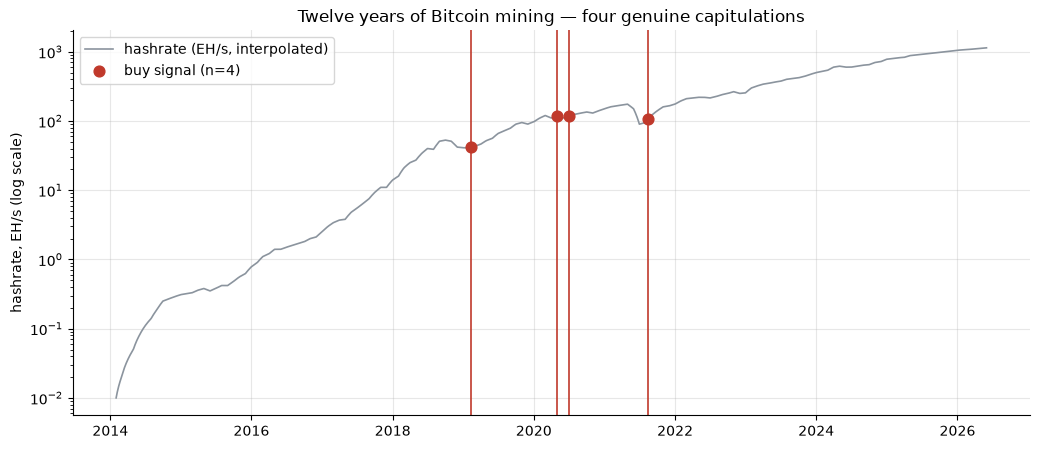

signal dates: [datetime.date(2019, 2, 12), datetime.date(2020, 4, 30), datetime.date(2020, 6, 30), datetime.date(2021, 8, 15)]


In [2]:
if HAVE_REAL:
    sig_dates = list(SIG['signal_date'])
else:
    sig_dates = pd.to_datetime([s['date'] for s in R['signals']])
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.plot(HR.index, HR.values, color=GREY, lw=1.2, label='hashrate (EH/s, interpolated)')
ax.set_yscale('log')
for d in sig_dates:
    ax.axvline(d, color=RED, lw=1.4, alpha=.85)
ax.scatter(sig_dates, [HR.reindex(sig_dates, method='nearest').loc[d] for d in sig_dates],
           color=RED, s=60, zorder=5, label=f'buy signal (n={len(sig_dates)})')
ax.set_ylabel('hashrate, EH/s (log scale)')
ax.set_title('Twelve years of Bitcoin mining — four genuine capitulations')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
print('signal dates:', [d.date() for d in sig_dates])

Four lines on twelve years of data. Each one marks a real, sizeable hashrate drop (8% to 44% peak-to-trough) followed by a recovery — 2018's mining bear market resolving in early 2019, the COVID crash and the May 2020 halving, and the 2021 China mining-ban exodus. **Now: what happened to price next?**

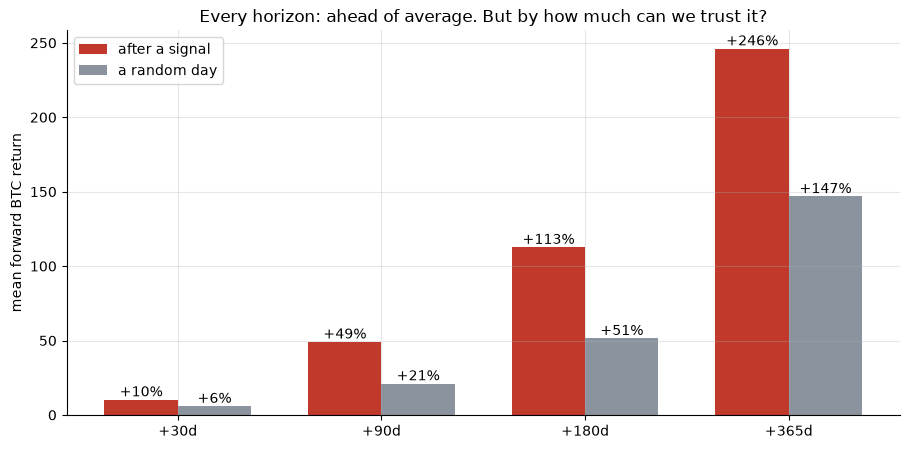

In [3]:
if HAVE_REAL:
    fr = st.forward_return_stats(BTC, SIG['signal_date'])
    sig_means = [fr.loc[h, 'signal_mean_pct'] for h in [30, 90, 180, 365]]
    unc_means = [fr.loc[h, 'uncond_mean_pct'] for h in [30, 90, 180, 365]]
else:
    sig_means = [R['fwd'][h][0] for h in [30, 90, 180, 365]]
    unc_means = [R['fwd'][h][2] for h in [30, 90, 180, 365]]
labels = ['+30d', '+90d', '+180d', '+365d']
x = np.arange(len(labels)); w = 0.36
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.bar(x - w/2, sig_means, width=w, color=RED, label='after a signal')
ax.bar(x + w/2, unc_means, width=w, color=GREY, label='a random day')
for i, v in enumerate(sig_means): ax.annotate(f'{v:+.0f}%', (x[i]-w/2, v), ha='center', va='bottom')
for i, v in enumerate(unc_means): ax.annotate(f'{v:+.0f}%', (x[i]+w/2, v), ha='center', va='bottom')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('mean forward BTC return')
ax.set_title('Every horizon: ahead of average. But by how much can we trust it?')
ax.legend(); plt.tight_layout(); plt.show()

Every bar is bigger after a signal than on a random day — at 6 months, **+113%** vs **+51%**. Looks great. Here's the catch — with only 4 events, how do we know that gap isn't just luck?

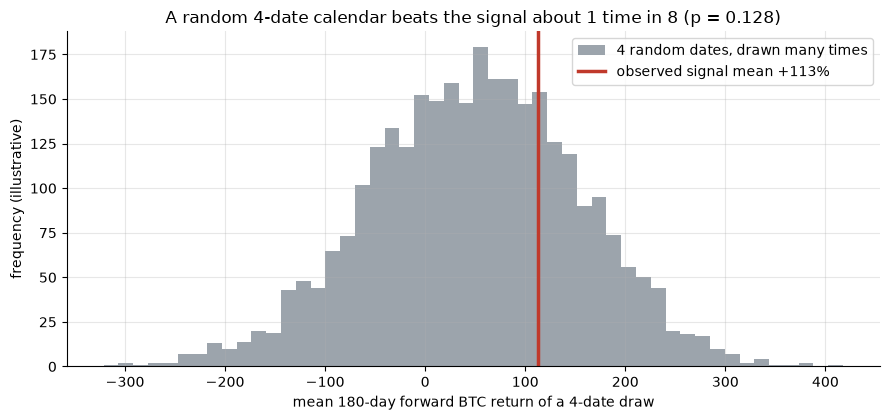

canonical placebo (results.md, 180d, 20,000 draws): p = 0.1278


In [4]:
if HAVE_REAL:
    p180 = fr.loc[180, 'placebo_p']
else:
    p180 = R['fwd'][180][5]
rng = np.random.default_rng(663)
draws = rng.normal(R['fwd'][180][2], R['fwd'][180][3], 3000)  # illustrative null shape
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='4 random dates, drawn many times')
ax.axvline(R['fwd'][180][0], color=RED, lw=2.5, label=f"observed signal mean +{R['fwd'][180][0]:.0f}%")
ax.set_xlabel('mean 180-day forward BTC return of a 4-date draw')
ax.set_ylabel('frequency (illustrative)')
ax.set_title(f'A random 4-date calendar beats the signal about 1 time in 8 (p = {p180:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'canonical placebo (results.md, 180d, {R["placebo_draws"]:,} draws): p = {p180:.4f}')

That's the honest picture: the signal's 6-month result sits inside the cloud a random calendar produces about **one time in eight** — nowhere close to the kind of "this almost never happens by chance" result the desk needs to call something **Real**. Now the trade check — would you have actually made money running this?

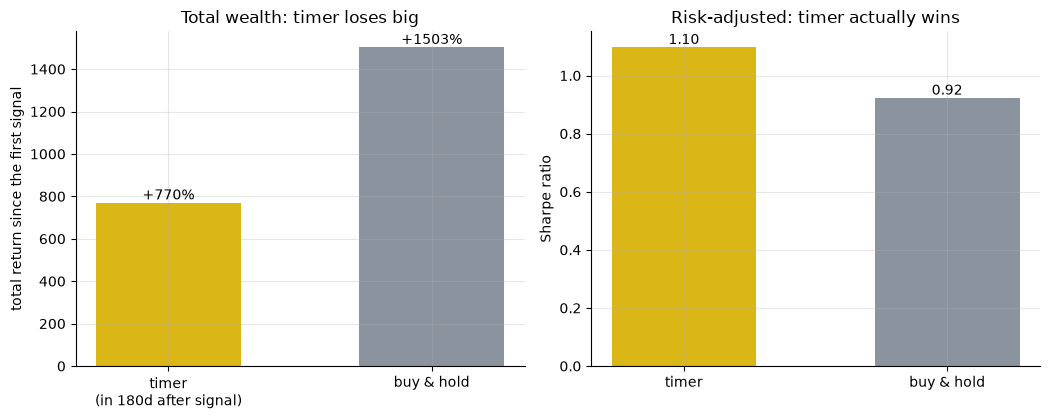

timer +770% (Sharpe 1.10)  vs  buy&hold +1503% (Sharpe 0.92)


In [5]:
if HAVE_REAL:
    tb = st.timer_backtest(BTC, SIG['signal_date'], hold_days=180, cost_bps=10.0)
    st_tot, bh_tot = tb['strat_total_pct'], tb['bh_total_pct']
    st_shp, bh_shp = tb['strat_sharpe'], tb['bh_sharpe']
else:
    st_tot, bh_tot = R['strat_total'], R['bh_total']
    st_shp, bh_shp = R['strat_sharpe'], R['bh_sharpe']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['timer\n(in 180d after signal)', 'buy & hold'], [st_tot, bh_tot], color=[AMBER, GREY], width=.55)
for i, v in enumerate([st_tot, bh_tot]): a1.annotate(f'{v:+.0f}%', (i, v), ha='center', va='bottom')
a1.set_ylabel('total return since the first signal'); a1.set_title('Total wealth: timer loses big')
a2.bar(['timer', 'buy & hold'], [st_shp, bh_shp], color=[AMBER, GREY], width=.55)
for i, v in enumerate([st_shp, bh_shp]): a2.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
a2.set_ylabel('Sharpe ratio'); a2.set_title('Risk-adjusted: timer actually wins')
plt.tight_layout(); plt.show()
print(f'timer {st_tot:+.0f}% (Sharpe {st_shp:.2f})  vs  buy&hold {bh_tot:+.0f}% (Sharpe {bh_shp:.2f})')

A split decision. Being long only **22%** of the time, but in the *right* 22%, genuinely smooths the ride — the Sharpe ratio is actually **better** than buy-and-hold (1.10 vs 0.92). But BTC spends most of its time going up, and sitting in cash the other 78% of the time means the timer ends with **less than half** the wealth (+770% vs +1503%). The signal doesn't beat buy-and-hold; it trades some upside for a smoother ride, on a strategy built from **3 actual holding periods**.

## 5 · The verdict

- **Signal — Weak.** Every horizon after a Hash Ribbons signal beat the unconditional average, but with only 4 (partly overlapping) events, nothing clears the bar for "statistically real" — the best placebo result still lets a random calendar win 1 time in 8.
- **Tradability — Fragile.** A timer built on the signal has a real Sharpe edge but gives up more than half the total wealth versus simply holding, built on just 3 distinct trades.
- **"Beats random buy dates?" — Busted.** Directionally ahead everywhere, never statistically proven anywhere.

## 6 · Going further 🚪

- **The n=4 problem is the whole story.** No amount of clever statistics turns four historical episodes into a certified edge. The honest use of Hash Ribbons is as a *narrative* input ("miners just capitulated, that's historically been a good sign") — not as a mechanical, backtestable trading signal.
- **What would change our mind:** true daily hashrate data (rather than an interpolated monthly series) and, mostly, *time* — another 5-10 genuine signals on the tape before the statistics have anything real to say.
- **Sibling studies:** [292-bitcoin-hashrate](../../292-bitcoin-hashrate/) already shows continuous hashrate-growth has **zero** predictive power for next-month returns — this study's narrower, event-based question gets a softer but still unproven answer.

*Think the 30/60-day windows or the 8% capitulation filter are cherry-picked? Fork the repo, try your own thresholds, and see if a different rule finds a cleaner signal in the same four historical windows — or a fifth one we missed.*